In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
np.load("dataset_1.npy")

array([[ 8.70870871, 24.35686446],
       [ 1.84184184, 11.67287386],
       [ 7.14714715, 23.22090435],
       [ 0.24024024,  9.45360006],
       [ 0.91091091, 12.04438067],
       [ 7.70770771, 28.22564539],
       [ 1.76176176, 15.61572335],
       [ 1.04104104, 14.09985815],
       [ 8.80880881, 26.57357495],
       [ 3.68368368, 16.76867156],
       [ 5.53553554, 21.32641829],
       [ 1.92192192, 13.15903186],
       [ 7.71771772, 23.38744614],
       [ 1.18118118,  9.90672714],
       [ 5.97597598, 23.31768388],
       [ 7.26726727, 24.24165347],
       [ 2.83283283, 13.38814968],
       [ 0.83083083, 12.00306019],
       [ 8.04804805, 24.15854971],
       [ 0.59059059, 15.97511847],
       [ 5.34534535, 23.03684028],
       [ 2.47247247, 16.75450726],
       [ 3.21321321, 14.6904655 ],
       [ 7.26726727, 26.2339229 ],
       [ 3.21321321, 17.16865737],
       [ 5.81581582, 19.4847581 ],
       [ 7.56756757, 25.78583725],
       [ 1.41141141, 14.9835214 ],
       [ 5.10510511,

7.a.i

Text(0.5, 1.0, 'dataset_2.npy')

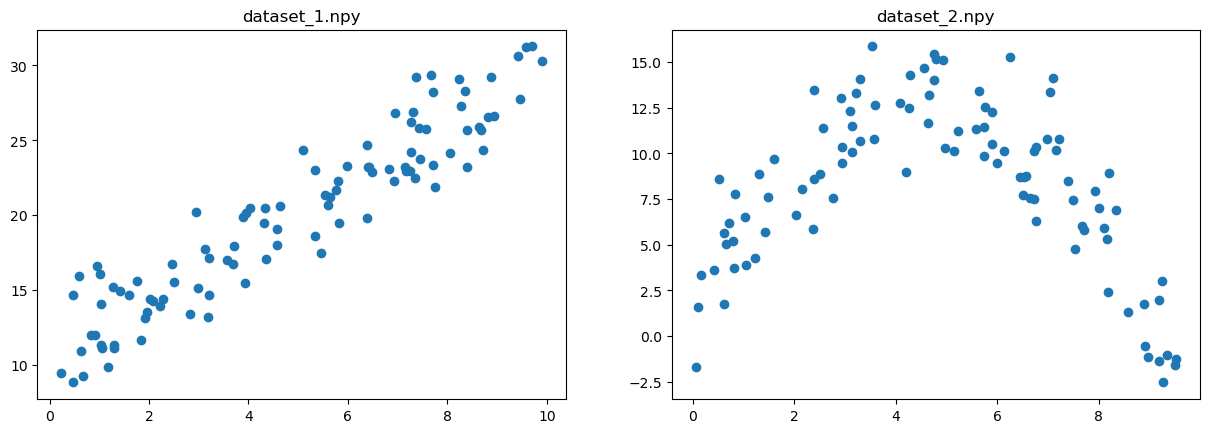

In [13]:
dataset1 = np.load("dataset_1.npy")
d1_x, d1_y = dataset1[:,0], dataset1[:,1]
dataset2 = np.load("dataset_2.npy")
d2_x, d2_y = dataset2[:,0], dataset2[:,1]

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(15)

ax1.scatter(d1_x, d1_y)
ax1.set_title("dataset_1.npy")

ax2.scatter(d2_x, d2_y)
ax2.set_title("dataset_2.npy")


$$ Cov(X, Y) = E[(X-\mu)(Y-\lambda)] $$

$$ \sigma^2 = \frac{\sum (x - \mu)^2 }{n} $$

In [38]:
dataset1 = np.load("dataset_1.npy")
d1_x, d1_y = dataset1[:,0], dataset1[:,1]

mu_x = sum(d1_x)/len(d1_x)
mu_y = sum(d1_y)/len(d1_y)
print("Average x: ", mu_x)
print("Average y: ", mu_y)

Lx, Ly = len(d1_x), len(d1_y)
assert Lx == Ly, "not equal"

# (x - mu_x)(y - mu_y) * probability
cov_xy = sum([(x - mu_x)*(y - mu_y) for (x, y) in zip(d1_x, d1_y) ])/(Lx)
print("covaraiance: ", cov_xy)

sigma_x = np.sqrt(sum([np.square(x - mu_x) for x in d1_x]) / Lx)
sigma_y = np.sqrt(sum([np.square(y - mu_y) for y in d1_y]) / Ly)
print("std x: ", sigma_x)
print("std y: ", sigma_y)

rho_xy = cov_xy/(sigma_x * sigma_y)
print("Mines: ", rho_xy)

print("Actual from numpy: ", np.corrcoef(d1_x, d1_y))


Average x:  4.900300300300298
Average y:  20.0079677246799
covaraiance:  15.560591375610526
std x:  2.8400137553510256
std y:  5.8343992401308284
Mines:  0.9390949620246671
Actual from numpy:  [[1.         0.93909496]
 [0.93909496 1.        ]]


Dataset 2

In [39]:
dataset1 = np.load("dataset_2.npy")
d1_x, d1_y = dataset1[:,0], dataset1[:,1]

mu_x = sum(d1_x)/len(d1_x)
mu_y = sum(d1_y)/len(d1_y)
print("Average x: ", mu_x)
print("Average y: ", mu_y)

Lx, Ly = len(d1_x), len(d1_y)
assert Lx == Ly, "not equal"

# (x - mu_x)(y - mu_y) * probability
cov_xy = sum([(x - mu_x)*(y - mu_y) for (x, y) in zip(d1_x, d1_y) ])/(Lx)
print("covaraiance: ", cov_xy)

sigma_x = np.sqrt(sum([np.square(x - mu_x) for x in d1_x]) / Lx)
sigma_y = np.sqrt(sum([np.square(y - mu_y) for y in d1_y]) / Ly)
print("std x: ", sigma_x)
print("std y: ", sigma_y)

rho_xy = cov_xy/(sigma_x * sigma_y)
print("Mines: ", rho_xy)

print("Actual from numpy: ", np.corrcoef(d1_x, d1_y))

Average x:  4.872072072072072
Average y:  8.183469680039929
covaraiance:  -2.262364435984757
std x:  2.789094562381731
std y:  4.5237606952776375
Mines:  -0.17930801518997472
Actual from numpy:  [[ 1.         -0.17930802]
 [-0.17930802  1.        ]]


##### Part C

finding w*

In [59]:
dataset1 = np.load("dataset_1.npy")
X, Y = dataset1[:,0], dataset1[:,1]

w = 1/np.dot(X,X) * np.dot(X, Y)
print("w*: ", w)

Loss = sum((X*w-Y)**2) / len(X)
Loss

w*:  3.541475210093868


32.027423422412085

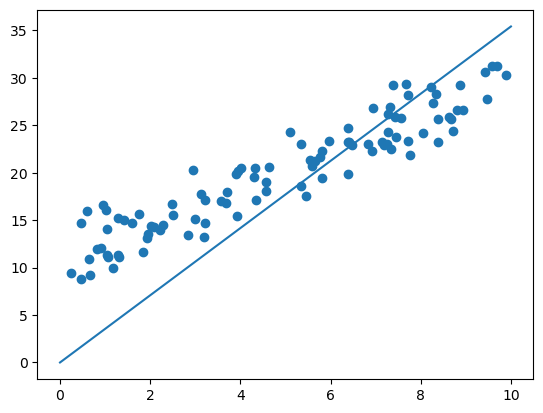

In [61]:
dataset1 = np.load("dataset_1.npy")
d1_x, d1_y = dataset1[:,0], dataset1[:,1]

plt.scatter(d1_x, d1_y)

x = np.linspace(0, 10, 100)
y = 3.541475210093868 * x
plt.plot(x, y)

#### Part D

In [73]:
dataset1 = np.load("dataset_1.npy")
X, Y = dataset1[:,0], dataset1[:,1]

X = np.vstack((np.ones(len(X)), X)).T

temp = np.linalg.inv(np.matmul(X.T, X))
temp = np.matmul(temp, X.T)
w = np.matmul(temp, Y)
print("w*: ", w)

Loss = sum((np.matmul(X,w)-Y)**2) / len(X)
Loss

w*:  [10.55413516  1.92923535]


4.020171536079681

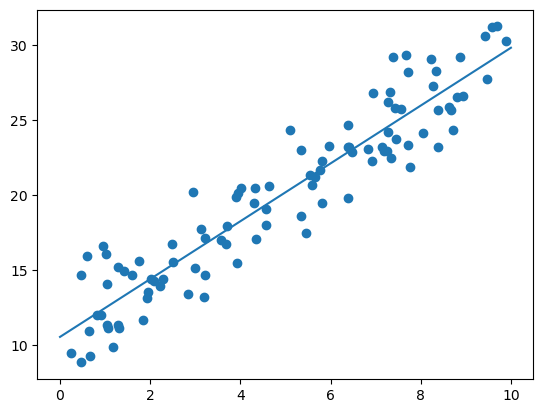

In [78]:
dataset1 = np.load("dataset_1.npy")
d1_x, d1_y = dataset1[:,0], dataset1[:,1]

plt.scatter(d1_x, d1_y)

x = np.linspace(0, 10, 100)
y = 1.92923535 * x + 10.55413516
plt.plot(x, y)

#### Part e

In [76]:
dataset1 = np.load("dataset_1.npy")
X, Y = dataset1[:,0], dataset1[:,1]

X = np.vstack((np.ones(len(X)), X, X**2)).T

temp = np.linalg.inv(np.matmul(X.T, X))
temp = np.matmul(temp, X.T)
w = np.matmul(temp, Y)
print("w*: ", w)

Loss = sum((np.matmul(X,w)-Y)**2) / len(X)
Loss

w*:  [10.79565856  1.77777908  0.01560721]


4.0093927596092325

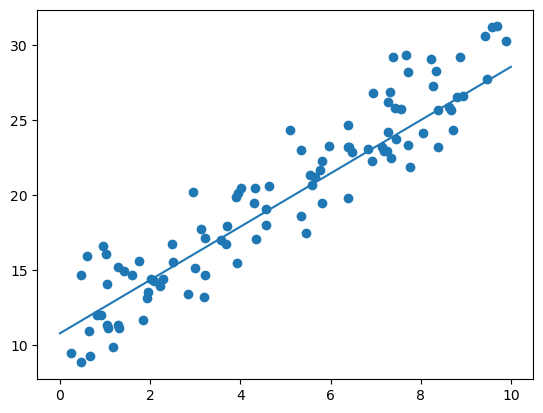

In [77]:
dataset1 = np.load("dataset_1.npy")
d1_x, d1_y = dataset1[:,0], dataset1[:,1]

plt.scatter(d1_x, d1_y)

x = np.linspace(0, 10, 100)
y = 0.01560721**2 + 1.77777908 * x + 10.79565856
plt.plot(x, y)

#### Part f

In [80]:
dataset = np.load("dataset_2.npy")
X, Y = dataset[:,0], dataset[:,1]

w = 1/np.dot(X,X) * np.dot(X, Y)
print("w*: ", w)

Loss = sum((X*w-Y)**2) / len(X)
Loss

w*:  1.1932963841881834


42.55598944292302

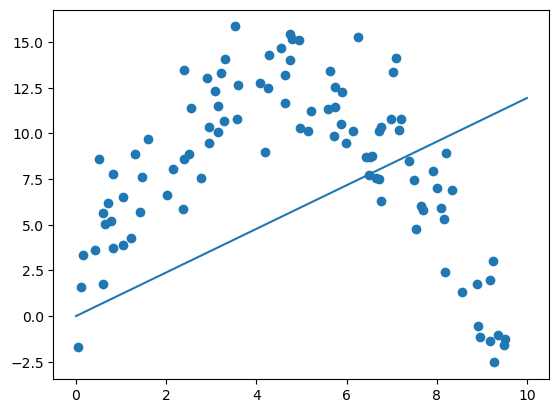

In [81]:
dataset = np.load("dataset_2.npy")
d_x, d_y = dataset[:,0], dataset[:,1]

plt.scatter(d_x, d_y)

x = np.linspace(0, 10, 100)
y = 1.1932963841881834 * x
plt.plot(x, y)

In [83]:

dataset = np.load("dataset_2.npy")
X, Y = dataset[:,0], dataset[:,1]

X = np.vstack((np.ones(len(X)), X)).T

temp = np.linalg.inv(np.matmul(X.T, X))
temp = np.matmul(temp, X.T)
w = np.matmul(temp, Y)
print("w*: ", w)


Loss = sum((np.matmul(X,w)-Y)**2) / len(X)
Loss

w*:  [ 9.60040423 -0.29082791]


19.806452100185833

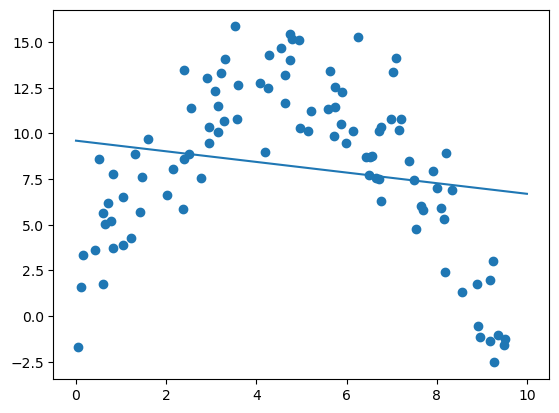

In [84]:
dataset = np.load("dataset_2.npy")
d_x, d_y = dataset[:,0], dataset[:,1]

plt.scatter(d_x, d_y)

x = np.linspace(0, 10, 100)
y = -0.29082791 * x + 9.60040423
plt.plot(x, y)

In [85]:

dataset = np.load("dataset_2.npy")
X, Y = dataset[:,0], dataset[:,1]

X = np.vstack((np.ones(len(X)), X, X**2)).T

temp = np.linalg.inv(np.matmul(X.T, X))
temp = np.matmul(temp, X.T)
w = np.matmul(temp, Y)
print("w*: ", w)


Loss = sum((np.matmul(X,w)-Y)**2) / len(X)
Loss

w*:  [ 1.29308851  5.04461079 -0.56121496]


4.2865237953828315

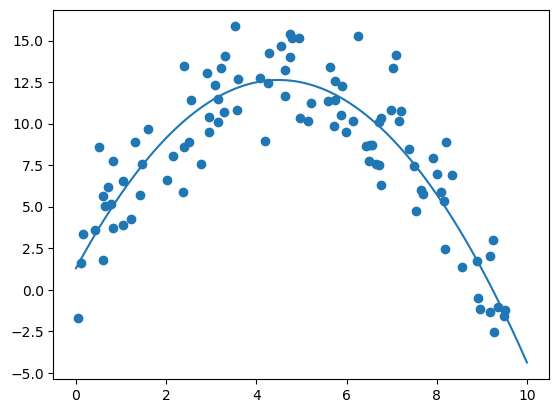

In [87]:
dataset = np.load("dataset_2.npy")
d_x, d_y = dataset[:,0], dataset[:,1]

plt.scatter(d_x, d_y)

x = np.linspace(0, 10, 100)
y = 1.29308851 + 5.04461079 * x + -0.56121496 * x**2
plt.plot(x, y)

#### Part G

(100, 6)
Subset  1
>degree  1
>Trained w*:  [9.35934093]
>Trained MSE:  14.24576486443215
>Val MSE:  39.385060742242395
>degree  2
>Trained w*:  [13.9000843  -0.84438105]
>Trained MSE:  10.866216295380177
>Val MSE:  32.1892503970771
>degree  3
>Trained w*:  [ 1.1084664   4.84561149 -0.52904387]
>Trained MSE:  3.7629440754618986
>Val MSE:  6.077183359737199
>degree  4
>Trained w*:  [-2.18912043  7.37423938 -1.06641795  0.03356674]
>Trained MSE:  3.6729393020088654
>Val MSE:  8.419949296692923
>degree  5
>Trained w*:  [ 20.71026543 -15.52532897   6.3452025   -0.9297178    0.0435055 ]
>Trained MSE:  2.9990375354231373
>Val MSE:  14.931366455418322
Subset  2
>degree  1
>Trained w*:  [7.11656426]
>Trained MSE:  22.592808162196334
>Val MSE:  24.32498427474867
>degree  2
>Trained w*:  [ 8.05736261 -0.19846828]
>Trained MSE:  22.23584262058743
>Val MSE:  24.939850631297166
>degree  3
>Trained w*:  [ 0.4181864   5.28432281 -0.58196108]
>Trained MSE:  3.559314519563273
>Val MSE:  7.0552813815111

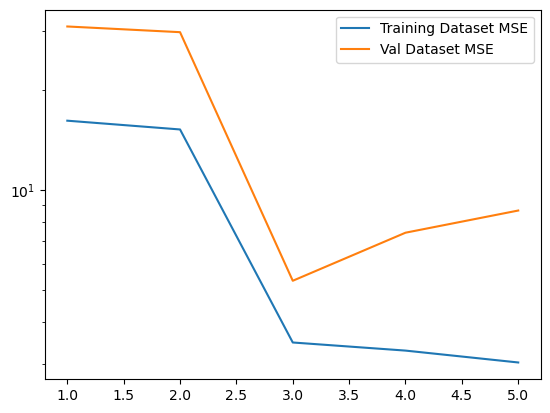

In [119]:
dataset = np.load("dataset_2.npy")
X, Y = dataset[:,0], dataset[:,1]

total = len(X)

# [ 
# 	[
# 		(X_train, Y_train), (X_test, Y_test)
#   ]
# ]


X = np.vstack((np.ones(len(X)), X, X**2, X**3, X**4, X**5)).T
print(X.shape)

train_averages = np.zeros(6)
test_averages = np.zeros(6)

split = 0.75
lastInd = 0
section = int(total/4)

for i in range(4):
	beg, end = int(i*section), int((i+1)*section)
	X_subset, Y_subset = X[beg:end], Y[beg:end]
	s = int(split*section)
	X_train, Y_train = X_subset[:s], Y_subset[:s]
	X_test, Y_test = X_subset[s:], Y_subset[s:]

	print("Subset ", i+1)
	
	for i in range(1,6):
		print(">degree ", i)
		x = X_train[:, :i]
		temp = np.linalg.inv(np.matmul(x.T, x))
		temp = np.matmul(temp, x.T)
		w = np.matmul(temp, Y_train)

		# trained w*
		print(">Trained w*: ", w)

		mse = sum((np.matmul(x[:,:i],w)-Y_train)**2) / len(X_train)
		print(">Trained MSE: ", mse)
		train_averages[i] += mse

		# testing MSE
		mse = sum((np.matmul(X_test[:,:i],w)-Y_test)**2) / len(X_test)
		print(">Val MSE: ", mse)
		test_averages[i] += mse

train_averages /= 4
test_averages /= 4
train_averages = train_averages[1:]
test_averages = test_averages[1:]

largest_degrees = np.arange(1, 6, 1)

plt.plot(largest_degrees, train_averages, label="Training Dataset MSE")
plt.plot(largest_degrees, test_averages, label="Val Dataset MSE")
plt.yscale('log')
plt.legend()
plt.show()
